# Supervised Learning - Stage 1

Stage 1 covers:
- Leakage removal
- Feature matrix construction for all three classification tasks
- Class imbalance analysis per task
- Stratified train/test split per task
- Imbalance strategy recommendation per task (informs Stage 2)

Three classification tasks are defined in `config.yml`:

| Task | Type | Target | Feature set |
|------|------|--------|-------------|
| multiclass | Multiclass | `collision_severity` | All non-leakage columns |
| binary | Binary | `urban_or_rural_area` | 5 road/environment columns |
| categorical | Categorical (multiclass) | `junction_detail` | 6 road classification columns |

---
# 1. Configuration and Imports

In [1]:
import os
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')


def find_project_root(marker='config.yml'):
    current = Path().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Could not find {marker} in any parent directory')


ROOT_DIR = find_project_root()
NOTEBOOKS_DIR = ROOT_DIR / 'notebooks'

with open(ROOT_DIR / 'config.yml') as f:
    cfg = yaml.safe_load(f)

with open(NOTEBOOKS_DIR / 'notebook-config.yml') as f:
    nb_cfg = yaml.safe_load(f)

NB_CONFIG = {
    'figsize_wide':    nb_cfg['plotting']['figsize_wide'],
    'figsize_square':  nb_cfg['plotting']['figsize_square'],
    'palette':         nb_cfg['plotting']['palette'],
    'severity_labels': {int(k): v for k, v in nb_cfg['labels']['severity'].items()},
}

sns.set_theme(style='whitegrid', palette=NB_CONFIG['palette'])
print(f'Project root: {ROOT_DIR}')
print('Pipeline config loaded from: config.yml')
print('Notebook config loaded from: notebook-config.yml')

Project root: /home/zayeer/Projects/Sheffield-Road-Collision-Detection-Coursework
Pipeline config loaded from: config.yml
Notebook config loaded from: notebook-config.yml


---
# 2. Load Clean Data

In [2]:
df = pd.read_csv(ROOT_DIR / cfg['preprocessing']['output_path'])

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Shape: (7324, 32)
Columns: ['collision_index', 'collision_year', 'location_easting_osgr', 'location_northing_osgr', 'collision_severity', 'number_of_vehicles', 'number_of_casualties', 'day_of_week', 'local_authority_highway_current', 'first_road_class', 'first_road_number', 'road_type', 'speed_limit', 'junction_detail', 'junction_control', 'second_road_class', 'second_road_number', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards', 'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident', 'trunk_road_flag', 'collision_injury_based', 'hour_of_day', 'month', 'is_weekend', 'time_period', 'multi_vehicle']


,collision_index,collision_year,location_easting_osgr,location_northing_osgr,collision_severity,number_of_vehicles,number_of_casualties,day_of_week,local_authority_highway_current,first_road_class,...,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,collision_injury_based,hour_of_day,month,is_weekend,time_period,multi_vehicle
0,2.02E+12,2020,1.000000,1.000000,3,0.5,1,5,E08000019,6,...,0,1,1,2.0,1,8,1,0,0,0
1,201514K199215,2015,1.000000,1.000000,2,0.5,1,1,E08000019,3,...,0,1,1,2.0,0,21,8,1,3,0
2,201514K276515,2015,0.782659,0.441915,3,0.5,1,1,E08000019,3,...,0,1,1,2.0,0,12,11,1,1,0


---
# 3. Leakage Removal

The following columns are dropped from the feature space across all tasks before any
task-specific feature selection is applied.

| Column | Reason |
|--------|--------|
| `collision_index` | Unique row identifier - no predictive signal |
| `collision_injury_based` | Directly derived from severity outcome - leakage |
| `local_authority_highway_current` | High-cardinality string, not numerically encoded |

In [3]:
leakage_cols = [c for c in cfg['supervised']['leakage_drop_cols'] if c in df.columns]
df_clean = df.drop(columns=leakage_cols)

print(f'Columns dropped as leakage: {leakage_cols}')
print(f'Shape after leakage removal: {df_clean.shape}')

Columns dropped as leakage: ['collision_index', 'collision_injury_based', 'local_authority_highway_current']
Shape after leakage removal: (7324, 29)


---
# 4. Feature Matrix Construction

Each task defines its own target and feature set in `config.yml`.
- `multiclass`: uses all remaining columns (no feature restriction)
- `binary` and `categorical`: use the explicit `feature_cols` lists defined in config

Each task also drops the *other* tasks' targets from its own feature matrix to prevent
cross-target leakage (e.g. `urban_or_rural_area` must not be a feature when it is also
a target in the binary task).

In [4]:
tasks_cfg = cfg['supervised']['tasks']

# All target columns across all tasks - must be excluded from each other's feature sets
all_targets = [tasks_cfg[task]['target_col'] for task in tasks_cfg]

task_data = {}

for task_name, task_def in tasks_cfg.items():
    target_col  = task_def['target_col']
    feature_cols = task_def['feature_cols']

    y = df_clean[target_col].copy()

    if feature_cols is None:
        # multiclass: use all columns except all task targets
        cols_to_exclude = all_targets
        X = df_clean.drop(columns=[c for c in cols_to_exclude if c in df_clean.columns])
    else:
        # binary / categorical: use only the specified feature cols
        available = [c for c in feature_cols if c in df_clean.columns]
        missing   = [c for c in feature_cols if c not in df_clean.columns]
        if missing:
            print(f'[{task_name}] WARNING: feature cols not found in dataframe: {missing}')
        X = df_clean[available].copy()

    task_data[task_name] = {'X': X, 'y': y}

    print(f'[{task_name}]')
    print(f'  Target:   {target_col}')
    print(f'  Features: {list(X.columns)}')
    print(f'  X shape:  {X.shape}')
    print()

[multiclass]
  Target:   collision_severity
  Features: ['collision_year', 'location_easting_osgr', 'location_northing_osgr', 'number_of_vehicles', 'number_of_casualties', 'day_of_week', 'first_road_class', 'first_road_number', 'road_type', 'speed_limit', 'junction_control', 'second_road_class', 'second_road_number', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards', 'did_police_officer_attend_scene_of_accident', 'trunk_road_flag', 'hour_of_day', 'month', 'is_weekend', 'time_period', 'multi_vehicle']
  X shape:  (7324, 26)

[binary]
  Target:   urban_or_rural_area
  Features: ['speed_limit', 'road_type', 'first_road_class', 'weather_conditions', 'light_conditions']
  X shape:  (7324, 5)

[categorical]
  Target:   junction_detail
  Features: ['first_road_class', 'second_road_class', 'first_road_number', 'second_road_number', 'road_type', 'speed_limit']
  X shape:  (7324, 6)



---
# 5. Class Imbalance Analysis

Before splitting, we examine the class distribution for each task. This determines
whether SMOTE is appropriate or whether `class_weight='balanced'` alone is sufficient
in Stage 2.

Decision thresholds used:
- Imbalance ratio >= 10:1 -> SMOTE warranted
- Any class with fewer than 6 samples -> SMOTE unsafe (k_neighbors=5 requires at least 6); use class_weight only
- Otherwise -> class_weight='balanced' is sufficient

In [5]:
SMOTE_RATIO_THRESHOLD   = 10.0  # imbalance ratio above which SMOTE is warranted
SMOTE_MIN_CLASS_SAMPLES = 6     # SMOTE k_neighbors=5 requires at least 6 samples per class


def get_label(task_name, cls, nb_cfg):
    """Return a human-readable label for a class value if a mapping exists."""
    if task_name == 'multiclass':
        return nb_cfg['labels']['severity'].get(str(cls), str(cls))
    return str(cls)


imbalance_summary = {}

for task_name, data in task_data.items():
    y = data['y']
    counts    = y.value_counts().sort_index()
    pcts      = (counts / len(y) * 100).round(2)
    ratio     = counts.max() / counts.min()
    min_count = counts.min()

    if min_count < SMOTE_MIN_CLASS_SAMPLES:
        strategy = 'class_weight only (class too small for SMOTE)'
    elif ratio >= SMOTE_RATIO_THRESHOLD:
        strategy = 'SMOTE + class_weight'
    else:
        strategy = 'class_weight only'

    imbalance_summary[task_name] = {
        'ratio':    ratio,
        'strategy': strategy,
        'counts':   counts,
        'pcts':     pcts,
    }

    print(f'[{task_name}] target={tasks_cfg[task_name]["target_col"]}')
    dist_df = pd.DataFrame({
        'Class': [get_label(task_name, c, nb_cfg) for c in counts.index],
        'Count': counts.values,
        'Percentage': pcts.values,
    })
    print(dist_df.to_string(index=False))
    print(f'  Imbalance ratio (majority:minority): {ratio:.1f}:1')
    print(f'  Recommended strategy: {strategy}')
    print()

[multiclass] target=collision_severity
Class  Count  Percentage
    1     93        1.27
    2   1129       15.42
    3   6102       83.32
  Imbalance ratio (majority:minority): 65.6:1
  Recommended strategy: SMOTE + class_weight

[binary] target=urban_or_rural_area
Class  Count  Percentage
    1   6908       94.32
    2    350        4.78
    3     66        0.90
  Imbalance ratio (majority:minority): 104.7:1
  Recommended strategy: SMOTE + class_weight

[categorical] target=junction_detail
Class  Count  Percentage
    0   2881       39.34
   13   2721       37.15
   16   1018       13.90
   17    213        2.91
   18    174        2.38
   19    317        4.33
  Imbalance ratio (majority:minority): 16.6:1
  Recommended strategy: SMOTE + class_weight



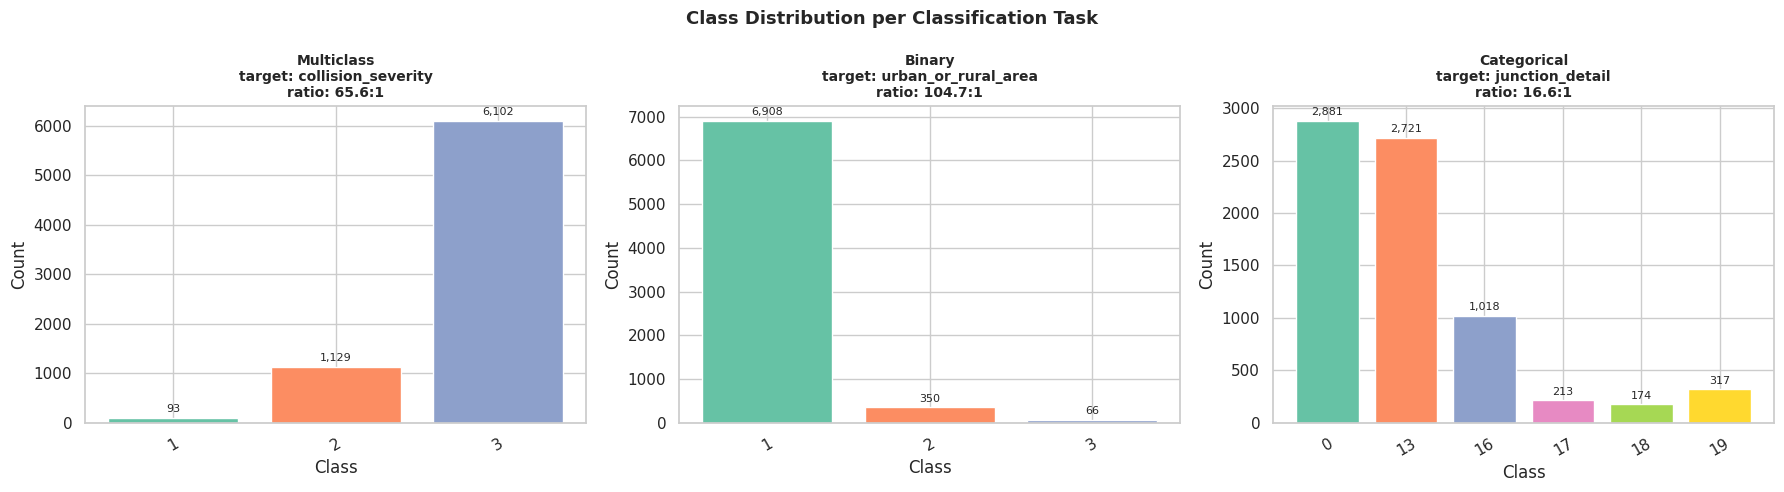

In [6]:
fig, axes = plt.subplots(1, len(task_data), figsize=(18, 5))
colors = sns.color_palette(NB_CONFIG['palette'])

for ax, (task_name, summary) in zip(axes, imbalance_summary.items()):
    counts = summary['counts']
    labels = [get_label(task_name, c, nb_cfg) for c in counts.index]

    bars = ax.bar(labels, counts.values, color=colors[:len(counts)], edgecolor='white')
    ax.set_title(
        f'{task_name.capitalize()}\n'
        f'target: {tasks_cfg[task_name]["target_col"]}\n'
        f'ratio: {summary["ratio"]:.1f}:1',
        fontsize=10, fontweight='bold'
    )
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)

    for bar, count in zip(bars, counts.values):
        ax.annotate(
            f'{count:,}',
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 4), textcoords='offset points',
            ha='center', fontsize=8
        )

fig.suptitle('Class Distribution per Classification Task', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 6. Stratified Train / Test Split

Each task gets its own stratified 80/20 split. Stratification preserves class proportions
in both splits - critical for imbalanced targets where minority classes could otherwise
be entirely absent from the test set by chance.

In [7]:
split_cfg = {
    'test_size':    cfg['supervised']['test_size'],
    'random_state': cfg['supervised']['random_state'],
}

for task_name, data in task_data.items():
    X, y = data['X'], data['y']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=split_cfg['test_size'],
        random_state=split_cfg['random_state'],
        stratify=y
    )

    task_data[task_name]['X_train'] = X_train
    task_data[task_name]['X_test']  = X_test
    task_data[task_name]['y_train'] = y_train
    task_data[task_name]['y_test']  = y_test

    print(f'[{task_name}]')
    print(f'  Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows')

    # Verify stratification held
    for split_name, y_split in [('Train', y_train), ('Test', y_test)]:
        split_counts = y_split.value_counts().sort_index()
        split_pcts   = (split_counts / len(y_split) * 100).round(1)
        dist_str = '  '.join(
            f"{get_label(task_name, c, nb_cfg)}={p}%"
            for c, p in zip(split_counts.index, split_pcts.values)
        )
        print(f'  {split_name}: {dist_str}')
    print()

[multiclass]
  Train: 5,859 rows  |  Test: 1,465 rows
  Train: 1=1.3%  2=15.4%  3=83.3%
  Test: 1=1.3%  2=15.4%  3=83.3%

[binary]
  Train: 5,859 rows  |  Test: 1,465 rows
  Train: 1=94.3%  2=4.8%  3=0.9%
  Test: 1=94.3%  2=4.8%  3=0.9%

[categorical]
  Train: 5,859 rows  |  Test: 1,465 rows
  Train: 0=39.3%  13=37.2%  16=13.9%  17=2.9%  18=2.4%  19=4.3%
  Test: 0=39.3%  13=37.1%  16=13.9%  17=2.9%  18=2.4%  19=4.3%



---
# 7. Stage 1 Summary

In [8]:
summary_rows = []
for task_name, data in task_data.items():
    summary_rows.append({
        'Task':              task_name,
        'Target':            tasks_cfg[task_name]['target_col'],
        'Features':          data['X_train'].shape[1],
        'Train samples':     data['X_train'].shape[0],
        'Test samples':      data['X_test'].shape[0],
        'Classes':           data['y_train'].nunique(),
        'Imbalance ratio':   f"{imbalance_summary[task_name]['ratio']:.1f}:1",
        'Stage 2 strategy':  imbalance_summary[task_name]['strategy'],
    })

summary_df = pd.DataFrame(summary_rows).set_index('Task')
print('Stage 1 Summary:')
summary_df

Stage 1 Summary:


,Target,Features,Train samples,Test samples,Classes,Imbalance ratio,Stage 2 strategy
Task,,,,,,,
multiclass,collision_severity,26,5859,1465,3,65.6:1,SMOTE + class_weight
binary,urban_or_rural_area,5,5859,1465,3,104.7:1,SMOTE + class_weight
categorical,junction_detail,6,5859,1465,6,16.6:1,SMOTE + class_weight


---
# 8. Persist Stage 1 Outputs

In [9]:
output_dir = NOTEBOOKS_DIR / 'stage_outputs'
os.makedirs(output_dir, exist_ok=True)

stage1_output = {
    task_name: {
        'X_train':           data['X_train'],
        'X_test':            data['X_test'],
        'y_train':           data['y_train'],
        'y_test':            data['y_test'],
        'imbalance_ratio':   imbalance_summary[task_name]['ratio'],
        'smote_strategy':    imbalance_summary[task_name]['strategy'],
    }
    for task_name, data in task_data.items()
}

output_path = output_dir / 'stage1.pkl'
with open(output_path, 'wb') as f:
    pickle.dump(stage1_output, f)

print(f'Stage 1 outputs saved to: {output_path}')
print()
print('Keys per task: X_train, X_test, y_train, y_test, imbalance_ratio, smote_strategy')
print()
for task_name in stage1_output:
    print(f'  stage1["{task_name}"] -> strategy: {stage1_output[task_name]["smote_strategy"]}')

Stage 1 outputs saved to: /home/zayeer/Projects/Sheffield-Road-Collision-Detection-Coursework/notebooks/stage_outputs/stage1.pkl

Keys per task: X_train, X_test, y_train, y_test, imbalance_ratio, smote_strategy

  stage1["multiclass"] -> strategy: SMOTE + class_weight
  stage1["binary"] -> strategy: SMOTE + class_weight
  stage1["categorical"] -> strategy: SMOTE + class_weight
